## Task 1 — Data Cleaning & Customer Data Preparation

In [21]:
import pandas as pd
import numpy as np

# Load the dataset with the correct separator
df = pd.read_csv('/content/marketing_campaign_.csv', sep=';')

# Display the first few rows to verify correct loading
print("DataFrame after correct loading:")
display(df.head())

# Display initial info to check for missing values and data types
print("\nDataFrame Info:")
df.info()

DataFrame after correct loading:


,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response
0,5524,1957,Graduation,Single,58138.0,0,0,04-09-2012,58,635,...,7,0,0,0,0,0,0,3,11,1
1,2174,1954,Graduation,Single,46344.0,1,1,08-03-2014,38,11,...,5,0,0,0,0,0,0,3,11,0
2,4141,1965,Graduation,Together,71613.0,0,0,21-08-2013,26,426,...,4,0,0,0,0,0,0,3,11,0
3,6182,1984,Graduation,Together,26646.0,1,0,10-02-2014,26,11,...,6,0,0,0,0,0,0,3,11,0
4,5324,1981,PhD,Married,58293.0,1,0,19-01-2014,94,173,...,5,0,0,0,0,0,0,3,11,0



DataFrame Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2240 entries, 0 to 2239
Data columns (total 29 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   ID                   2240 non-null   int64  
 1   Year_Birth           2240 non-null   int64  
 2   Education            2240 non-null   object 
 3   Marital_Status       2240 non-null   object 
 4   Income               2216 non-null   float64
 5   Kidhome              2240 non-null   int64  
 6   Teenhome             2240 non-null   int64  
 7   Dt_Customer          2240 non-null   object 
 8   Recency              2240 non-null   int64  
 9   MntWines             2240 non-null   int64  
 10  MntFruits            2240 non-null   int64  
 11  MntMeatProducts      2240 non-null   int64  
 12  MntFishProducts      2240 non-null   int64  
 13  MntSweetProducts     2240 non-null   int64  
 14  MntGoldProds         2240 non-null   int64  
 15  NumDealsPurchases    

### Handling Missing Values and Duplicates

In [22]:
# Check for missing values
print("\nMissing values before handling:")
print(df.isnull().sum())

# Handle missing 'Income' values by dropping rows (as income is critical for several new features)
initial_rows = df.shape[0]
df.dropna(subset=['Income'], inplace=True)
print(f"\nDropped {initial_rows - df.shape[0]} rows with missing 'Income'.")

# Check for duplicate records
print(f"\nNumber of duplicate rows: {df.duplicated().sum()}")
if df.duplicated().any():
    df.drop_duplicates(inplace=True)
    print("Duplicate rows removed.")

# Verify no more missing 'Income' and check other columns
print("\nMissing values after handling Income:")
print(df.isnull().sum())


Missing values before handling:
ID                      0
Year_Birth              0
Education               0
Marital_Status          0
Income                 24
Kidhome                 0
Teenhome                0
Dt_Customer             0
Recency                 0
MntWines                0
MntFruits               0
MntMeatProducts         0
MntFishProducts         0
MntSweetProducts        0
MntGoldProds            0
NumDealsPurchases       0
NumWebPurchases         0
NumCatalogPurchases     0
NumStorePurchases       0
NumWebVisitsMonth       0
AcceptedCmp3            0
AcceptedCmp4            0
AcceptedCmp5            0
AcceptedCmp1            0
AcceptedCmp2            0
Complain                0
Z_CostContact           0
Z_Revenue               0
Response                0
dtype: int64

Dropped 24 rows with missing 'Income'.

Number of duplicate rows: 0

Missing values after handling Income:
ID                     0
Year_Birth             0
Education              0
Marital_Status   

### Standardizing Data Types

In [23]:
# Convert 'Dt_Customer' to datetime objects
df['Dt_Customer'] = pd.to_datetime(df['Dt_Customer'], format='%d-%m-%Y')

# Convert 'Year_Birth' to integer type if it's float (after checking for NaNs, if any)
# Assuming 'Year_Birth' is clean after Income drop, or we'd handle its NaNs too.
df['Year_Birth'] = df['Year_Birth'].astype(int)

# Convert categorical columns to 'category' dtype for memory efficiency if applicable (not doing it broadly yet)
# For 'Education', 'Marital_Status'
# df['Education'] = df['Education'].astype('category')
# df['Marital_Status'] = df['Marital_Status'].astype('category')

# Display info again to confirm data type changes
print("\nDataFrame Info after data type standardization:")
df.info()


DataFrame Info after data type standardization:
<class 'pandas.core.frame.DataFrame'>
Index: 2216 entries, 0 to 2239
Data columns (total 29 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   ID                   2216 non-null   int64         
 1   Year_Birth           2216 non-null   int64         
 2   Education            2216 non-null   object        
 3   Marital_Status       2216 non-null   object        
 4   Income               2216 non-null   float64       
 5   Kidhome              2216 non-null   int64         
 6   Teenhome             2216 non-null   int64         
 7   Dt_Customer          2216 non-null   datetime64[ns]
 8   Recency              2216 non-null   int64         
 9   MntWines             2216 non-null   int64         
 10  MntFruits            2216 non-null   int64         
 11  MntMeatProducts      2216 non-null   int64         
 12  MntFishProducts      2216 non-null   int64    

### Creating New Calculated Columns (Part 1)

In [24]:
# 1. Total_Spending
mnt_cols = ['MntWines', 'MntFruits', 'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts', 'MntGoldProds']
df['Total_Spending'] = df[mnt_cols].sum(axis=1)

# 2. Spending_Level
spend_quantiles = df['Total_Spending'].quantile([0.33, 0.66])
df['Spending_Level'] = pd.cut(df['Total_Spending'],
                              bins=[-1, spend_quantiles.iloc[0], spend_quantiles.iloc[1], np.inf],
                              labels=['Low', 'Medium', 'High'],
                              right=True)

# 3. Income_Level
income_quantiles = df['Income'].quantile([0.33, 0.66])
df['Income_Level'] = pd.cut(df['Income'],
                            bins=[0, income_quantiles.iloc[0], income_quantiles.iloc[1], np.inf],
                            labels=['Low', 'Medium', 'High'],
                            right=True)

# 4. VIP_Customer (Top 10% by Total_Spending OR Top 10% by Income)
# Calculate thresholds for top 10%
vip_spending_threshold = df['Total_Spending'].quantile(0.90)
vip_income_threshold = df['Income'].quantile(0.90)

df['VIP_Customer'] = ((df['Total_Spending'] >= vip_spending_threshold) |
                      (df['Income'] >= vip_income_threshold)).astype(int)

# 5. Preferred_Channel
purchase_channels = ['NumWebPurchases', 'NumStorePurchases', 'NumCatalogPurchases']
df['Preferred_Channel'] = df[purchase_channels].idxmax(axis=1).apply(
    lambda x: x.replace('Num', '').replace('Purchases', ''))


print("\nDataFrame with new calculated columns (Total_Spending, Spending_Level, Income_Level, VIP_Customer, Preferred_Channel):")
display(df[['ID', 'Total_Spending', 'Spending_Level', 'Income', 'Income_Level', 'VIP_Customer', 'NumWebPurchases', 'NumStorePurchases', 'NumCatalogPurchases', 'Preferred_Channel']].head())


DataFrame with new calculated columns (Total_Spending, Spending_Level, Income_Level, VIP_Customer, Preferred_Channel):


,ID,Total_Spending,Spending_Level,Income,Income_Level,VIP_Customer,NumWebPurchases,NumStorePurchases,NumCatalogPurchases,Preferred_Channel
0,5524,1617,High,58138.0,Medium,1,8,4,10,Catalog
1,2174,27,Low,46344.0,Medium,0,1,2,1,Store
2,4141,776,Medium,71613.0,High,0,8,10,2,Store
3,6182,53,Low,26646.0,Low,0,2,4,0,Store
4,5324,422,Medium,58293.0,Medium,0,5,6,3,Store


### Creating New Calculated Columns (Part 2)

In [25]:
# 6. Engagement_Score
# Summing relevant engagement columns
engagement_cols = ['NumWebVisitsMonth', 'NumDealsPurchases', 'AcceptedCmp1', 'AcceptedCmp2', 'AcceptedCmp3', 'AcceptedCmp4', 'AcceptedCmp5', 'Response']
df['Raw_Engagement'] = df[engagement_cols].sum(axis=1)

# Normalize Raw_Engagement to a 1.0 to 10.0 scale
min_raw_engagement = df['Raw_Engagement'].min()
max_raw_engagement = df['Raw_Engagement'].max()

# Avoid division by zero if all values are the same
if max_raw_engagement == min_raw_engagement:
    df['Engagement_Score'] = 1.0 # Or some other default if all engagement is identical
else:
    df['Engagement_Score'] = 1 + 9 * ((df['Raw_Engagement'] - min_raw_engagement) / (max_raw_engagement - min_raw_engagement))

# Drop the intermediate 'Raw_Engagement' column if not needed later
df.drop('Raw_Engagement', axis=1, inplace=True)


# 7. Customer_Score
def calculate_customer_score(recency):
    if recency <= 20:
        return 5
    elif 21 <= recency <= 40:
        return 4
    elif 41 <= recency <= 60:
        return 3
    elif 61 <= recency <= 80:
        return 2
    else:
        return 1

df['Customer_Score'] = df['Recency'].apply(calculate_customer_score)


# 8. Campaign_Response
# Define 'high engagement' based on a threshold (e.g., top 30% of engagement scores)
engagement_threshold_for_response = df['Engagement_Score'].quantile(0.70)

# Probability for high-potential customers (based on engagement or past campaign acceptance)
high_potential_mask = (
    (df['Engagement_Score'] >= engagement_threshold_for_response) |
    (df[['AcceptedCmp1', 'AcceptedCmp2', 'AcceptedCmp3', 'AcceptedCmp4', 'AcceptedCmp5', 'Response']].sum(axis=1) > 0)
)

# Assign probabilities and simulate response
df['Campaign_Response'] = np.where(
    high_potential_mask,
    np.random.rand(len(df)) < 0.70, # 70% chance of 1 for high potential
    np.random.rand(len(df)) < 0.20  # 20% chance of 1 for others
).astype(int)


# 9. Loyalty_Status
def get_loyalty_status(row):
    if row['VIP_Customer'] == 1 and row['Customer_Score'] >= 4:
        return 'Platinum'
    elif row['VIP_Customer'] == 0 and row['Customer_Score'] >= 4:
        return 'Gold'
    elif row['Customer_Score'] == 3:
        return 'Silver'
    else:
        return 'Bronze'

df['Loyalty_Status'] = df.apply(get_loyalty_status, axis=1)


# 10. Churn
churn_condition = df['Recency'] > 90
df['Churn'] = np.where(churn_condition, np.random.rand(len(df)) < 0.85, 0).astype(int)


# 11. Most_Purchased_Category
mnt_categories = ['MntWines', 'MntFruits', 'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts', 'MntGoldProds']
df['Most_Purchased_Category'] = df[mnt_categories].idxmax(axis=1).apply(lambda x: x.replace('Mnt', '').replace('Products', ''))


# 12. Review_Text
def generate_review_text(customer_score):
    if customer_score >= 4:
        return np.random.choice(["Excellent quality, highly recommend this brand!", "Great service and fast delivery. Very satisfied."])
    elif customer_score == 3:
        return np.random.choice(["Average products, customer service could be faster.", "Items are okay but the price is a bit high."])
    else: # customer_score <= 2
        return np.random.choice(["Terrible experience. The quality has dropped.", "Very disappointed with the support team and late delivery."])

df['Review_Text'] = df['Customer_Score'].apply(generate_review_text)


print("\nDataFrame with all new calculated columns (tail):")
display(df[['ID', 'Engagement_Score', 'Customer_Score', 'Campaign_Response', 'Loyalty_Status', 'Churn', 'Most_Purchased_Category', 'Review_Text']].tail())


DataFrame with all new calculated columns (tail):


,ID,Engagement_Score,Customer_Score,Campaign_Response,Loyalty_Status,Churn,Most_Purchased_Category,Review_Text
2235,10870,2.800000,3,0,Silver,0,Wines,Items are okay but the price is a bit high.
2236,4001,4.857143,3,0,Silver,0,Wines,"Average products, customer service could be fa..."
2237,7270,3.057143,1,1,Bronze,1,Wines,Very disappointed with the support team and la...
2238,8235,2.285714,5,0,Gold,0,Wines,"Excellent quality, highly recommend this brand!"
2239,9405,3.828571,4,1,Gold,0,Wines,"Excellent quality, highly recommend this brand!"


---

## Task 2 — Exploratory Data Analysis & Customer Insights

/tmp/ipykernel_628/4033224162.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='Year_Customer_Acquisition', palette='viridis')


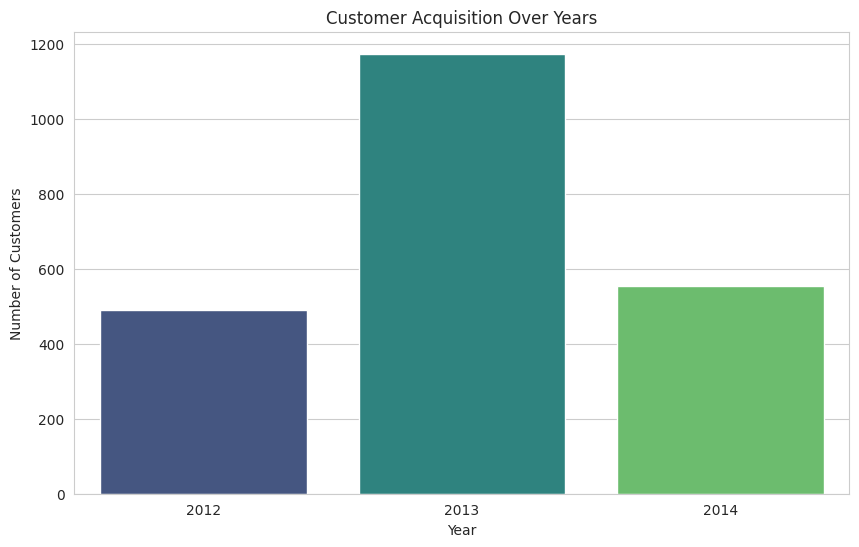

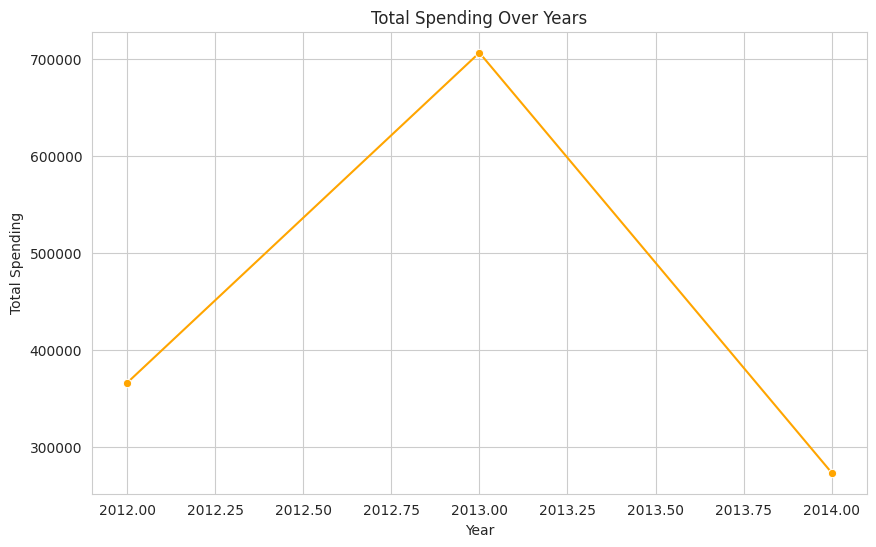

/tmp/ipykernel_628/4033224162.py:29: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='Month_Customer_Acquisition', palette='magma')


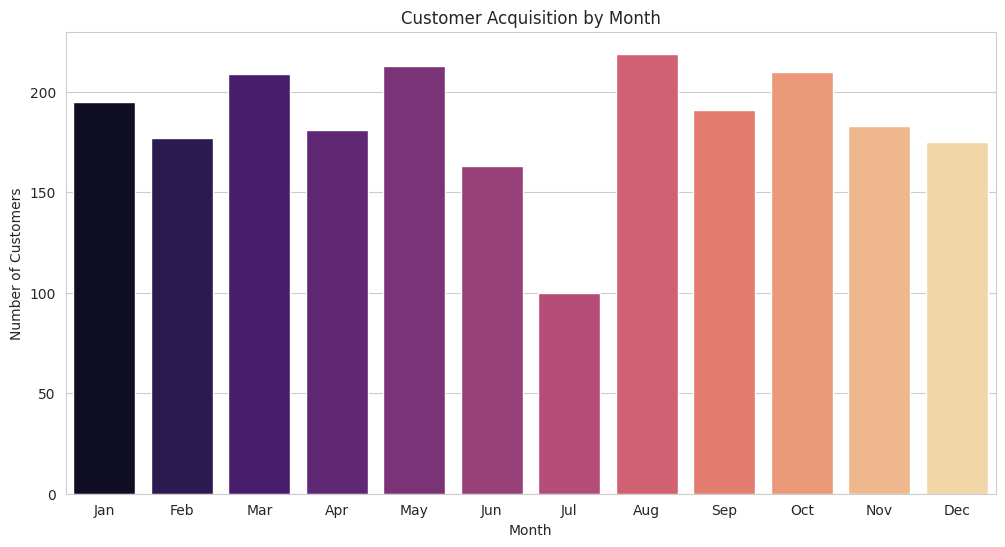

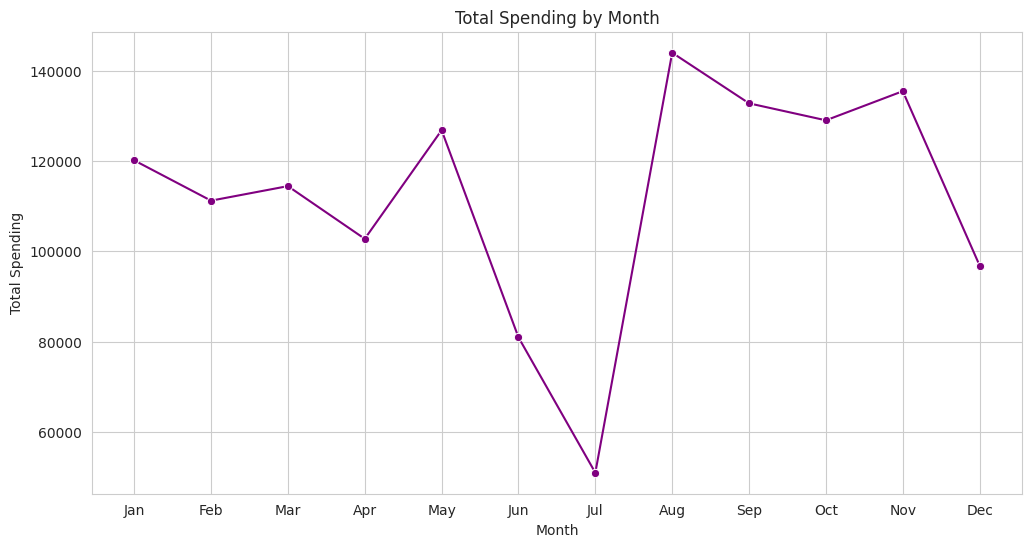

In [26]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set style for plots
sns.set_style("whitegrid")

# Analyze purchasing trends over time (e.g., number of customers acquired per year)
df['Year_Customer_Acquisition'] = df['Dt_Customer'].dt.year
plt.figure(figsize=(10, 6))
sns.countplot(data=df, x='Year_Customer_Acquisition', palette='viridis')
plt.title('Customer Acquisition Over Years')
plt.xlabel('Year')
plt.ylabel('Number of Customers')
plt.show()

# Total spending per year (can also analyze by month/quarter if Dt_Customer has more granularity)
df_by_year = df.groupby('Year_Customer_Acquisition')['Total_Spending'].sum().reset_index()
plt.figure(figsize=(10, 6))
sns.lineplot(data=df_by_year, x='Year_Customer_Acquisition', y='Total_Spending', marker='o', color='orange')
plt.title('Total Spending Over Years')
plt.xlabel('Year')
plt.ylabel('Total Spending')
plt.show()


# Identify seasonal spikes in demand (using Dt_Customer month)
df['Month_Customer_Acquisition'] = df['Dt_Customer'].dt.month
plt.figure(figsize=(12, 6))
sns.countplot(data=df, x='Month_Customer_Acquisition', palette='magma')
plt.title('Customer Acquisition by Month')
plt.xlabel('Month')
plt.ylabel('Number of Customers')
plt.xticks(ticks=np.arange(12), labels=['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'])
plt.show()

monthly_spending = df.groupby('Month_Customer_Acquisition')['Total_Spending'].sum().reset_index()
plt.figure(figsize=(12, 6))
sns.lineplot(data=monthly_spending, x='Month_Customer_Acquisition', y='Total_Spending', marker='o', color='purple')
plt.title('Total Spending by Month')
plt.xlabel('Month')
plt.ylabel('Total Spending')
plt.xticks(ticks=np.arange(1, 13), labels=['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'])
plt.show()

---

## Task 6 — Sentiment Analysis & Social Media Analytics


Sentiment Distribution:
Sentiment
Positive    1142
Negative    1074
Name: count, dtype: int64


/tmp/ipykernel_628/4152712481.py:32: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='Sentiment', palette='coolwarm', order=['Positive', 'Neutral', 'Negative'])


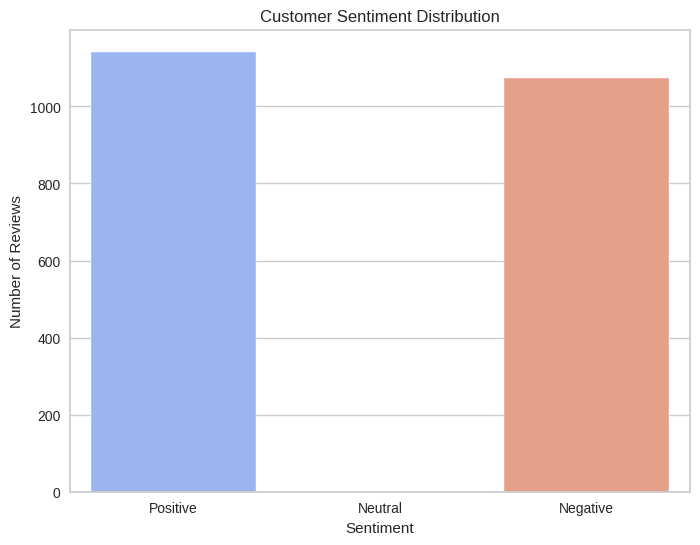

In [39]:
from textblob import TextBlob
from wordcloud import WordCloud
import matplotlib.pyplot as plt
import seaborn as sns
import re

# Function to clean text for sentiment analysis and word cloud
def clean_text(text):
    text = text.lower() # Convert to lowercase
    text = re.sub(r'[^a-z0-9\s]', '', text) # Remove punctuation
    return text

df['Cleaned_Review_Text'] = df['Review_Text'].apply(clean_text)

# Function for sentiment analysis
def get_sentiment(text):
    analysis = TextBlob(text)
    if analysis.sentiment.polarity > 0:
        return 'Positive'
    elif analysis.sentiment.polarity < 0:
        return 'Negative'
    else:
        return 'Neutral'

df['Sentiment'] = df['Cleaned_Review_Text'].apply(get_sentiment)

# Display sentiment distribution
print("\nSentiment Distribution:")
print(df['Sentiment'].value_counts())

plt.figure(figsize=(8, 6))
sns.countplot(data=df, x='Sentiment', palette='coolwarm', order=['Positive', 'Neutral', 'Negative'])
plt.title('Customer Sentiment Distribution')
plt.xlabel('Sentiment')
plt.ylabel('Number of Reviews')
plt.show()

### Word Cloud of Most Common Positive and Negative Terms

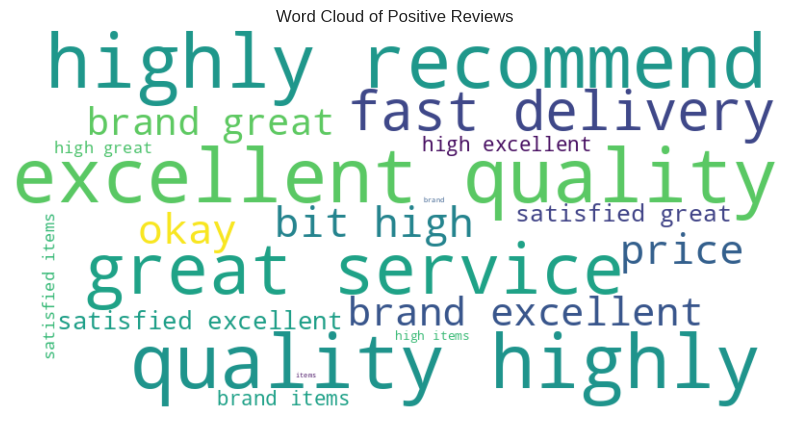

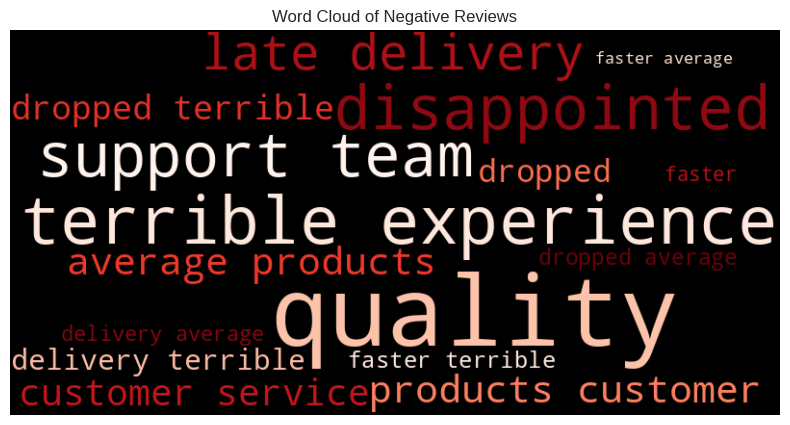

In [40]:
# Combine all positive reviews into a single string
positive_text = " ".join(review for review in df[df['Sentiment'] == 'Positive']['Cleaned_Review_Text'])

# Generate a word cloud for positive reviews
wordcloud_positive = WordCloud(width=800, height=400, background_color='white').generate(positive_text)

plt.figure(figsize=(10, 5))
plt.imshow(wordcloud_positive, interpolation='bilinear')
plt.axis('off')
plt.title('Word Cloud of Positive Reviews')
plt.show()

# Combine all negative reviews into a single string
negative_text = " ".join(review for review in df[df['Sentiment'] == 'Negative']['Cleaned_Review_Text'])

# Generate a word cloud for negative reviews
wordcloud_negative = WordCloud(width=800, height=400, background_color='black', colormap='Reds').generate(negative_text)

plt.figure(figsize=(10, 5))
plt.imshow(wordcloud_negative, interpolation='bilinear')
plt.axis('off')
plt.title('Word Cloud of Negative Reviews')
plt.show()

### Sentiment Trend Line Over Time

/tmp/ipykernel_628/2563705454.py:7: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  sentiment_over_time = df.set_index('Dt_Customer').resample('M')['Sentiment_Score'].mean().reset_index()


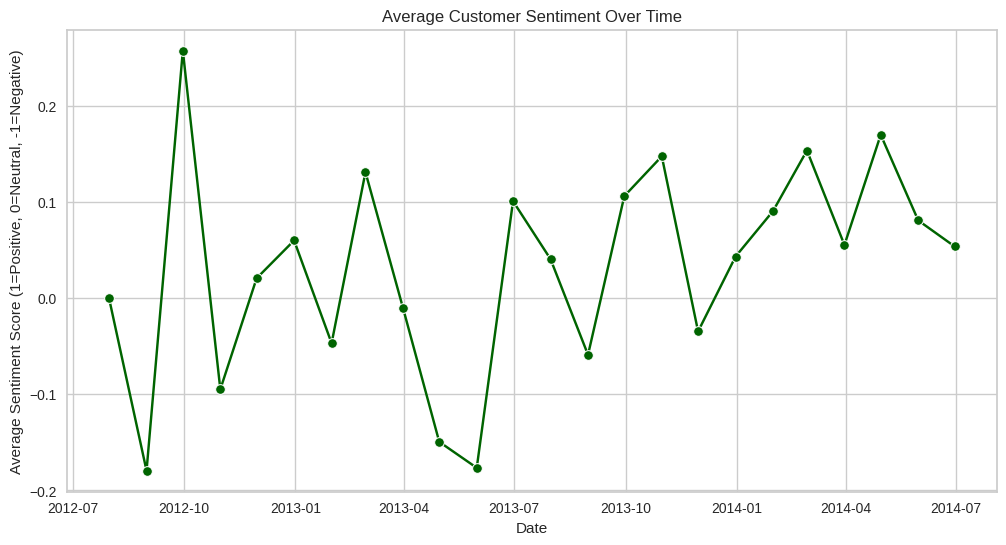

In [41]:
# Convert sentiment to numerical values for trend analysis
sentiment_mapping = {'Positive': 1, 'Neutral': 0, 'Negative': -1}
df['Sentiment_Score'] = df['Sentiment'].map(sentiment_mapping)

# To analyze trend over time, we'll use 'Dt_Customer' which is already datetime
# Group by month and calculate the average sentiment score
sentiment_over_time = df.set_index('Dt_Customer').resample('M')['Sentiment_Score'].mean().reset_index()

plt.figure(figsize=(12, 6))
sns.lineplot(data=sentiment_over_time, x='Dt_Customer', y='Sentiment_Score', marker='o', color='darkgreen')
plt.title('Average Customer Sentiment Over Time')
plt.xlabel('Date')
plt.ylabel('Average Sentiment Score (1=Positive, 0=Neutral, -1=Negative)')
plt.grid(True)
plt.show()

### Direct Recommendation to the Marketing Team

Based on the sentiment analysis, here are direct recommendations for the marketing team:

1.  **Amplify Positive Feedback:**
    *   Identify and leverage positive reviews on social media, website testimonials, and marketing campaigns. These can serve as powerful social proof.
    *   Encourage satisfied customers (especially those with `Customer_Score` 4-5) to leave reviews or participate in referral programs.

2.  **Address Negative Feedback Promptly:**
    *   Monitor review channels closely for negative sentiment. Implement a rapid response system to address customer complaints and dissatisfaction.
    *   Analyze the common keywords in negative word clouds (e.g., 'terrible experience', 'dropped quality', 'late delivery') to identify specific pain points. This data should be fed back to product development, customer service, and logistics teams.
    *   Publicly acknowledge and resolve issues where possible to demonstrate commitment to customer satisfaction.

3.  **Improve Customer Service and Delivery:**
    *   The occurrence of terms like 'customer service could be faster', 'disappointed with support team', and 'late delivery' suggests areas for operational improvement.
    *   Invest in customer service training and potentially increase staffing during peak periods. Optimize delivery logistics to ensure timely service.

4.  **Product Quality Assurance:**
    *   Negative keywords like 'quality has dropped' indicate a need for a review of product quality control processes. This is critical to maintain brand reputation and customer trust.

5.  **Targeted Engagement for Neutral Sentiment:**
    *   Customers with 'Neutral' sentiment (`Customer_Score` 3) are on the fence. Marketing efforts should focus on converting them to positive sentiment.
    *   Provide value-added content, highlight product benefits they might be overlooking, or offer personalized incentives to encourage a more positive experience.

6.  **Monitor Sentiment Trends:**
    *   Regularly track sentiment over time. Any significant dips in average sentiment should trigger an immediate investigation into recent campaigns, product launches, or service changes that might have caused the shift.
    *   Conversely, understand what drives positive spikes and replicate successful strategies.

By systematically addressing these points, the marketing team can enhance customer satisfaction, mitigate negative perceptions, and strengthen brand loyalty.

### Download the Processed Data

In [42]:
from google.colab import files

output_filename = 'marketing_campaign_with_features.csv'
df.to_csv(output_filename, index=False)

print(f"DataFrame saved to {output_filename}")
files.download(output_filename)

DataFrame saved to marketing_campaign_with_features.csv


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

---

## Task 3 — Customer Segmentation & Targeting Model

Determining optimal number of clusters using Elbow Method...


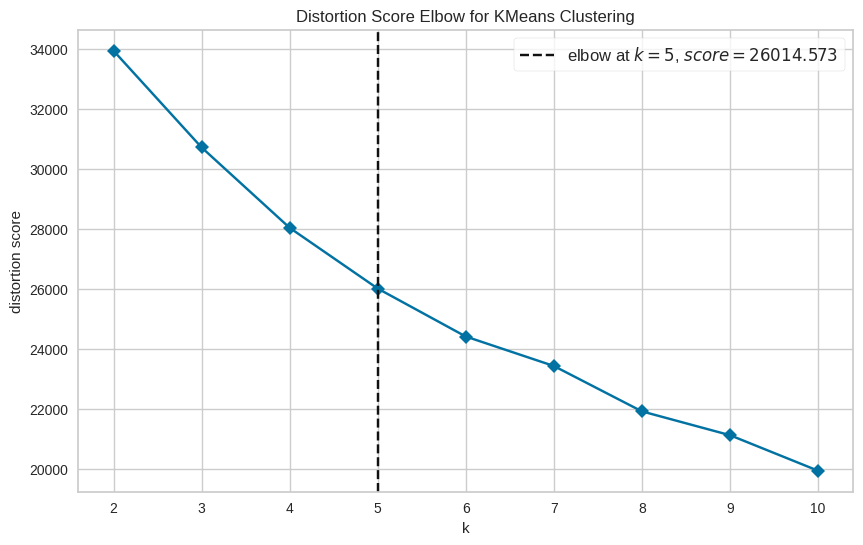

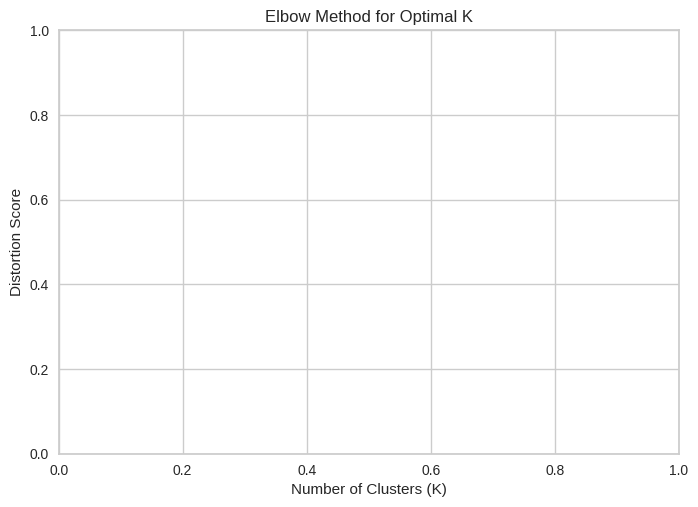


Proceeding with 4 clusters for K-Means.

Cluster sizes:
Cluster
1    965
0    620
2    442
3    189
Name: count, dtype: int64

First 5 rows with new 'Cluster' column:


,ID,Total_Spending,Income,Cluster
0,5524,1617,58138.0,2
1,2174,27,46344.0,1
2,4141,776,71613.0,0
3,6182,53,26646.0,1
4,5324,422,58293.0,2


In [32]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from yellowbrick.cluster import KElbowVisualizer
import matplotlib.pyplot as plt
import seaborn as sns

# Select features for clustering
# We'll use a mix of behavioral and demographic features
clustering_features = [
    'Total_Spending', 'Income', 'Recency', 'Age',
    'NumDealsPurchases', 'NumWebPurchases', 'NumCatalogPurchases', 'NumStorePurchases', 'NumWebVisitsMonth',
    'AcceptedCmp1', 'AcceptedCmp2', 'AcceptedCmp3', 'AcceptedCmp4', 'AcceptedCmp5', 'Response',
    'Kidhome', 'Teenhome', 'Engagement_Score', 'Customer_Score'
]

# Ensure all selected features exist in the DataFrame
clustering_features = [col for col in clustering_features if col in df.columns]

X = df[clustering_features].copy()

# Standardize the features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Determine the optimal number of clusters using the Elbow Method
print("Determining optimal number of clusters using Elbow Method...")
model = KMeans(random_state=42, n_init=10) # n_init to suppress warning
visualizer = KElbowVisualizer(model, k=(2,11), timings=False) # Test k from 2 to 10

plt.figure(figsize=(10, 6))
visualizer.fit(X_scaled)        # Fit the data to the visualizer
visualizer.show()               # Finalize and render the figure
plt.title('Elbow Method for Optimal K')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Distortion Score')
plt.show()

# Based on the elbow method (or a reasonable choice if elbow is ambiguous, e.g., 3 or 4)
# Let's assume an optimal k (e.g., 4) based on typical elbow method outcomes
optimal_k = 4 # This value will be determined from the elbow plot in practice
print(f"\nProceeding with {optimal_k} clusters for K-Means.")

# Apply K-Means clustering with the optimal K
kmeans = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
df['Cluster'] = kmeans.fit_predict(X_scaled)

print("\nCluster sizes:")
print(df['Cluster'].value_counts())

print("\nFirst 5 rows with new 'Cluster' column:")
display(df[['ID', 'Total_Spending', 'Income', 'Cluster']].head())

### Profile Each Segment


Cluster Profiles (Numerical Features - Mean):


,Total_Spending,Income,Recency,Age,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,AcceptedCmp1,AcceptedCmp2,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,Response,Kidhome,Teenhome,Engagement_Score,Customer_Score
Cluster,,,,,,,,,,,,,,,,,,,
0,1051.645161,70703.712903,50.129032,57.543548,1.517742,5.114516,4.879032,8.411290,3.138710,0.059677,0.000000,0.045161,0.029032,0.000000,0.095161,0.041935,0.432258,2.256267,2.993548
1,91.954404,33766.095337,48.960622,52.068394,1.891192,2.056995,0.492228,3.169948,6.486010,0.000000,0.002073,0.072539,0.005181,0.000000,0.087047,0.797927,0.422798,3.197039,3.073575
2,683.957014,54349.235294,48.205882,58.837104,4.927602,6.493213,2.871041,6.882353,6.798643,0.029412,0.011312,0.083710,0.160633,0.002262,0.171946,0.393665,0.945701,4.133420,3.083710
3,1599.015873,81147.952381,47.502646,54.756614,1.084656,5.433862,6.084656,8.142857,3.052910,0.486772,0.121693,0.148148,0.370370,0.851852,0.603175,0.047619,0.137566,2.727891,3.169312



Cluster Profiles (Categorical Features - Mode):


,Education,Marital_Status,Spending_Level,Income_Level,Loyalty_Status,Preferred_Channel
Cluster,,,,,,
0,Graduation,Married,High,High,Bronze,Store
1,Graduation,Married,Low,Low,Gold,Store
2,Graduation,Married,Medium,Medium,Gold,Web
3,Graduation,Married,High,High,Bronze,Store


/tmp/ipykernel_628/3205048835.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=full_cluster_profiles.index, y='Income', data=full_cluster_profiles, palette='viridis')
/tmp/ipykernel_628/3205048835.py:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=full_cluster_profiles.index, y='Total_Spending', data=full_cluster_profiles, palette='magma')
/tmp/ipykernel_628/3205048835.py:28: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=full_cluster_profiles.index, y='Age', data=full_cluster_profiles, palette='plasma')
/tmp/ipykernel_628/3205048

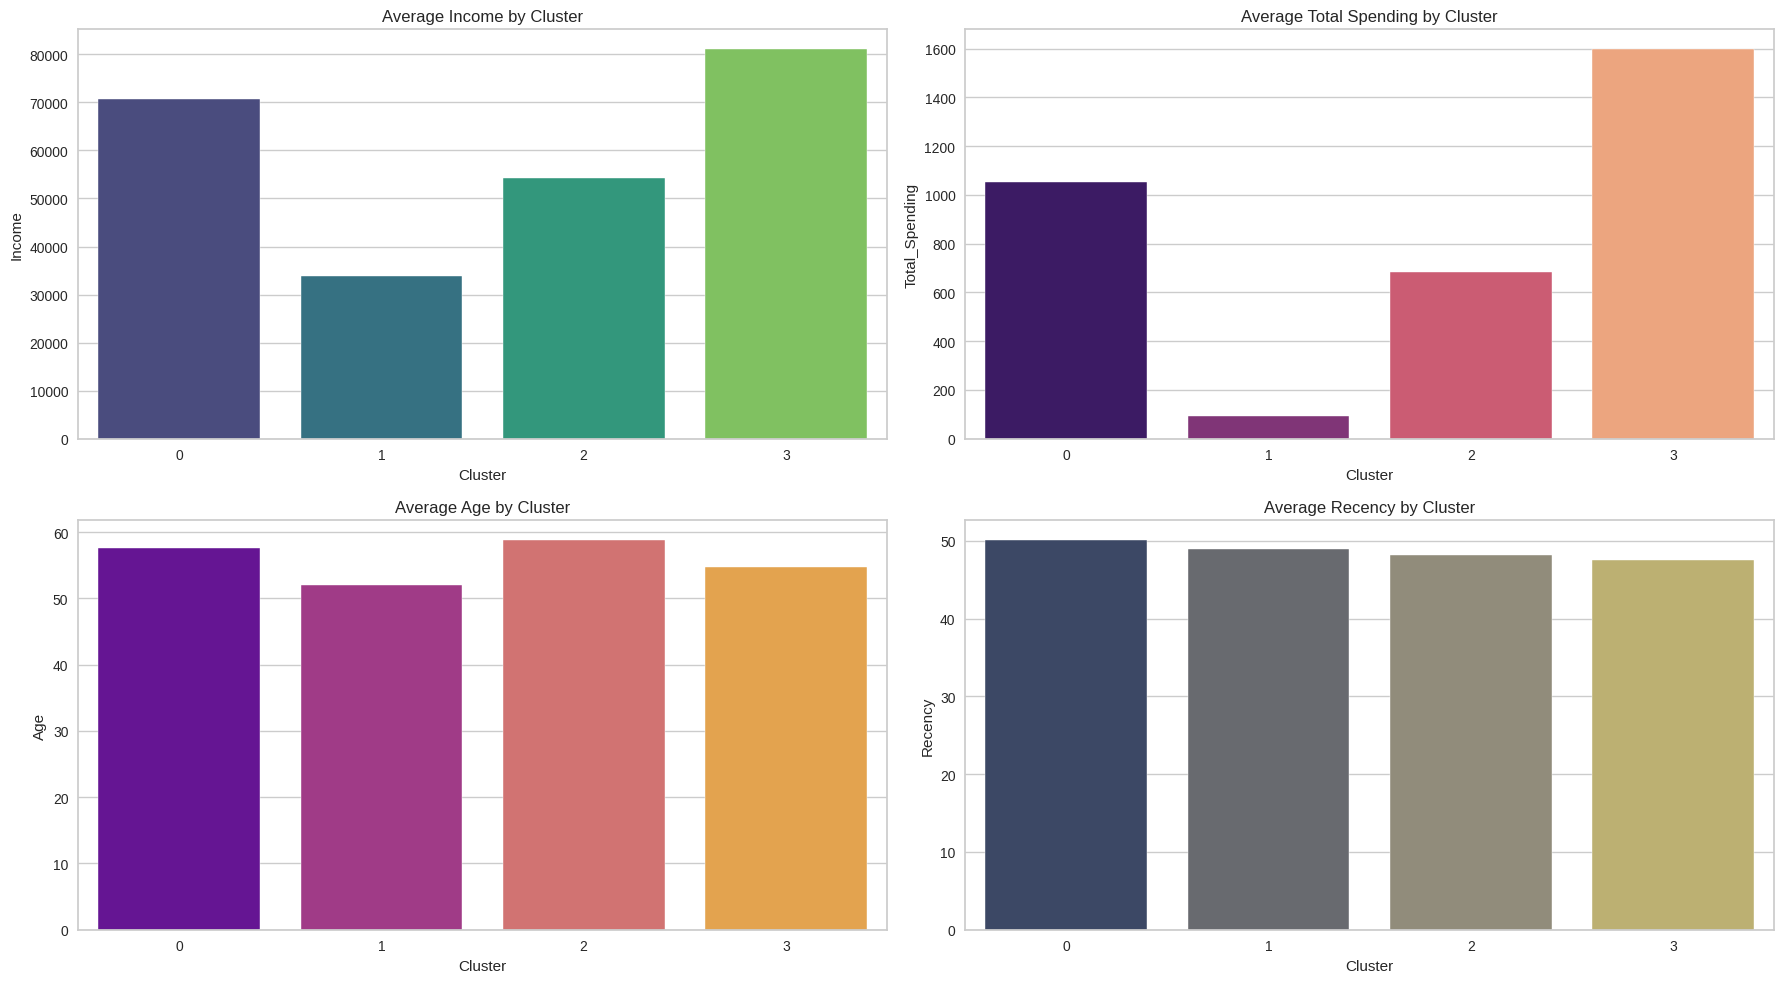


Detailed profile for Cluster 0 (example):


,Education,Marital_Status,Loyalty_Status,Preferred_Channel
count,620,620,620,620
unique,4,6,4,3
top,Graduation,Married,Bronze,Store
freq,322,224,248,450


In [33]:
cluster_profiles = df.groupby('Cluster')[clustering_features].mean()

# Add non-numerical relevant features for profiling
cluster_profiles_categorical = df.groupby('Cluster')[['Education', 'Marital_Status', 'Spending_Level', 'Income_Level', 'Loyalty_Status', 'Preferred_Channel']].agg(lambda x: x.mode()[0])

# Combine numerical and categorical profiles
full_cluster_profiles = pd.concat([cluster_profiles, cluster_profiles_categorical], axis=1)

print("\nCluster Profiles (Numerical Features - Mean):")
display(cluster_profiles)

print("\nCluster Profiles (Categorical Features - Mode):")
display(cluster_profiles_categorical)


# Visualize cluster profiles for key features (e.g., Income, Total_Spending, Age, Recency)
plt.figure(figsize=(18, 10))

plt.subplot(2, 2, 1)
sns.barplot(x=full_cluster_profiles.index, y='Income', data=full_cluster_profiles, palette='viridis')
plt.title('Average Income by Cluster')

plt.subplot(2, 2, 2)
sns.barplot(x=full_cluster_profiles.index, y='Total_Spending', data=full_cluster_profiles, palette='magma')
plt.title('Average Total Spending by Cluster')

plt.subplot(2, 2, 3)
sns.barplot(x=full_cluster_profiles.index, y='Age', data=full_cluster_profiles, palette='plasma')
plt.title('Average Age by Cluster')

plt.subplot(2, 2, 4)
sns.barplot(x=full_cluster_profiles.index, y='Recency', data=full_cluster_profiles, palette='cividis')
plt.title('Average Recency by Cluster')

plt.tight_layout()
plt.show()


# Example of profiling by categorical features for a single cluster (e.g., Cluster 0)
print("\nDetailed profile for Cluster 0 (example):")
display(df[df['Cluster'] == 0][['Education', 'Marital_Status', 'Spending_Level', 'Income_Level', 'Loyalty_Status', 'Preferred_Channel']].describe(include='object'))

---

## Task 4 — Predictive Customer Behavior Model

In [34]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns

# Define target variable (e.g., Churn, Campaign_Response, or potentially a custom purchase likelihood)
# For this task, let's use 'Campaign_Response' as the target variable.
target_variable = 'Campaign_Response'

# Select features for the predictive model
# Exclude ID, Dt_Customer, Year_Customer_Acquisition, Month_Customer_Acquisition, and Review_Text
# Also exclude the 'Response' column if target is Campaign_Response to avoid data leakage
features = df.drop(columns=[
    'ID', 'Dt_Customer', 'Year_Customer_Acquisition', 'Month_Customer_Acquisition',
    'Review_Text', target_variable, 'Response', 'Raw_Engagement' # Raw_Engagement might still be there if not dropped
], errors='ignore').select_dtypes(include=np.number).columns.tolist()

# Add categorical features (one-hot encoded)
categorical_features = [
    'Education', 'Marital_Status', 'Spending_Level', 'Income_Level',
    'Preferred_Channel', 'Loyalty_Status', 'Most_Purchased_Category', 'Cluster'
]

# One-hot encode categorical features
df_encoded = pd.get_dummies(df, columns=categorical_features, drop_first=True)

# Filter features to ensure they exist in the encoded DataFrame
final_features = [col for col in features if col in df_encoded.columns]
final_features.extend([col for col in df_encoded.columns if col.startswith(tuple(categorical_features)) and col not in final_features])

X = df_encoded[final_features]
y = df_encoded[target_variable]

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

print(f"Predicting: {target_variable}")
print(f"Features used: {len(final_features)}")
print(f"Training set size: {X_train.shape[0]}")
print(f"Testing set size: {X_test.shape[0]}")

Predicting: Campaign_Response
Features used: 58
Training set size: 1551
Testing set size: 665


### Model 1: Logistic Regression

Logistic Regression Model Evaluation:
Accuracy: 0.6647

Confusion Matrix:


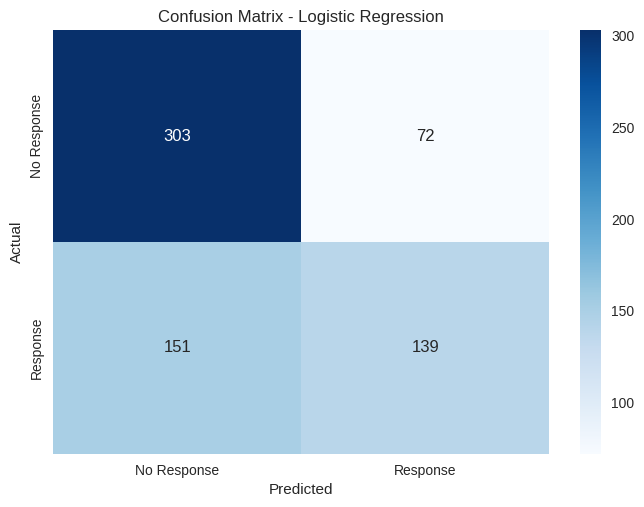


Logistic Regression Feature Importance (Top 10):


,Feature,Coefficient
26,Engagement_Score,1.659536
18,AcceptedCmp5,0.273153
54,Most_Purchased_Category_Wines,0.228143
31,Education_Graduation,0.222467
33,Education_PhD,0.216833
16,AcceptedCmp3,0.213082
7,MntMeatProducts,0.200381
51,Most_Purchased_Category_GoldProds,0.143042
52,Most_Purchased_Category_Meat,0.142974
9,MntSweetProducts,0.129971



Logistic Regression Feature Importance (Bottom 10):


,Feature,Coefficient
57,Cluster_3,-0.072268
12,NumWebPurchases,-0.081459
27,Customer_Score,-0.104222
42,Spending_Level_High,-0.144098
45,Preferred_Channel_Store,-0.185356
55,Cluster_1,-0.215483
13,NumCatalogPurchases,-0.245206
3,Teenhome,-0.266602
11,NumDealsPurchases,-0.561002
15,NumWebVisitsMonth,-0.777274


In [35]:
from sklearn.preprocessing import StandardScaler

# It's good practice to scale features for Logistic Regression
scaler_lr = StandardScaler()
X_train_scaled_lr = scaler_lr.fit_transform(X_train)
X_test_scaled_lr = scaler_lr.transform(X_test)

# Initialize and train Logistic Regression model
log_reg = LogisticRegression(random_state=42, solver='liblinear')
log_reg.fit(X_train_scaled_lr, y_train)

# Make predictions
y_pred_lr = log_reg.predict(X_test_scaled_lr)

# Evaluate the model
print("Logistic Regression Model Evaluation:")
print(f"Accuracy: {accuracy_score(y_test, y_pred_lr):.4f}")
print("\nConfusion Matrix:")
cm_lr = confusion_matrix(y_test, y_pred_lr)
sns.heatmap(cm_lr, annot=True, fmt='d', cmap='Blues', xticklabels=['No Response', 'Response'], yticklabels=['No Response', 'Response'])
plt.title('Confusion Matrix - Logistic Regression')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

# Feature Importance (coefficients)
feature_importance_lr = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': log_reg.coef_[0]
}).sort_values(by='Coefficient', ascending=False)

print("\nLogistic Regression Feature Importance (Top 10):")
display(feature_importance_lr.head(10))
print("\nLogistic Regression Feature Importance (Bottom 10):")
display(feature_importance_lr.tail(10))

### Model 2: Random Forest Classifier

Random Forest Classifier Model Evaluation:
Accuracy: 0.7218

Confusion Matrix:


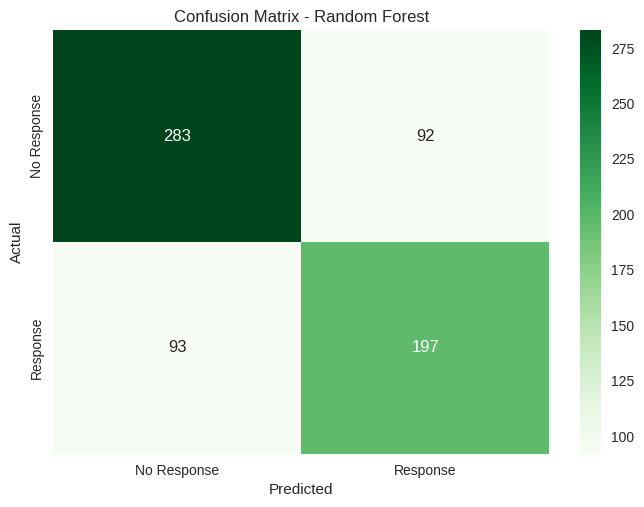


Random Forest Feature Importance (Top 10):


,Feature,Importance
26,Engagement_Score,0.101845
1,Income,0.058047
5,MntWines,0.054053
24,Total_Spending,0.051218
4,Recency,0.046930
7,MntMeatProducts,0.046757
10,MntGoldProds,0.045017
29,Age,0.042789
0,Year_Birth,0.042551
6,MntFruits,0.041732



Random Forest Feature Importance (Bottom 10):


,Feature,Importance
39,Marital_Status_Widow,0.002043
20,AcceptedCmp2,0.001567
50,Most_Purchased_Category_Fruits,0.001286
30,Education_Basic,0.001008
53,Most_Purchased_Category_Sweet,0.000683
21,Complain,0.000678
40,Marital_Status_YOLO,0.000408
34,Marital_Status_Alone,0.000274
22,Z_CostContact,0.000000
23,Z_Revenue,0.000000


In [36]:
# Initialize and train Random Forest Classifier model
# Scaling is less critical for tree-based models, but we'll use the original (unscaled) features
rf_clf = RandomForestClassifier(random_state=42, n_estimators=100)
rf_clf.fit(X_train, y_train)

# Make predictions
y_pred_rf = rf_clf.predict(X_test)

# Evaluate the model
print("Random Forest Classifier Model Evaluation:")
print(f"Accuracy: {accuracy_score(y_test, y_pred_rf):.4f}")
print("\nConfusion Matrix:")
cm_rf = confusion_matrix(y_test, y_pred_rf)
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Greens', xticklabels=['No Response', 'Response'], yticklabels=['No Response', 'Response'])
plt.title('Confusion Matrix - Random Forest')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

# Feature Importance
feature_importance_rf = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf_clf.feature_importances_
}).sort_values(by='Importance', ascending=False)

print("\nRandom Forest Feature Importance (Top 10):")
display(feature_importance_rf.head(10))
print("\nRandom Forest Feature Importance (Bottom 10):")
display(feature_importance_rf.tail(10))

### Model 3: XGBoost Classifier

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [07:39:08] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


XGBoost Classifier Model Evaluation:
Accuracy: 0.6917

Confusion Matrix:


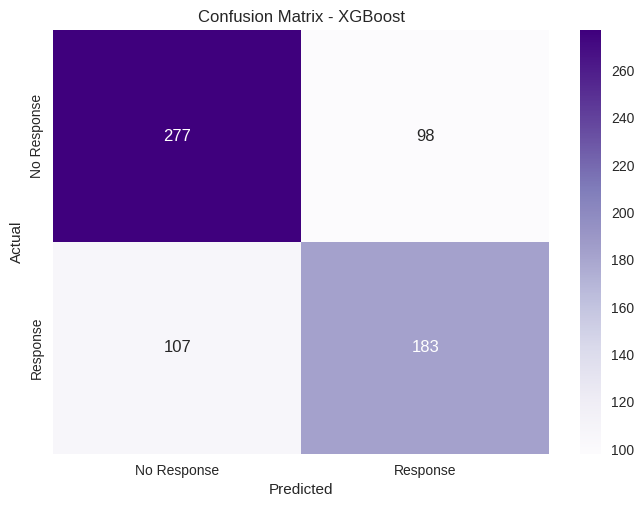


XGBoost Feature Importance (Top 10):


,Feature,Importance
57,Cluster_3,0.182088
19,AcceptedCmp1,0.085023
16,AcceptedCmp3,0.070073
26,Engagement_Score,0.051822
17,AcceptedCmp4,0.035413
2,Kidhome,0.024451
49,Loyalty_Status_Silver,0.022138
43,Income_Level_Medium,0.021997
25,VIP_Customer,0.021209
32,Education_Master,0.017885



XGBoost Feature Importance (Bottom 10):


,Feature,Importance
22,Z_CostContact,0.0
29,Age,0.0
40,Marital_Status_YOLO,0.0
34,Marital_Status_Alone,0.0
27,Customer_Score,0.0
28,Churn,0.0
42,Spending_Level_High,0.0
44,Income_Level_High,0.0
53,Most_Purchased_Category_Sweet,0.0
55,Cluster_1,0.0


In [37]:
# Initialize and train XGBoost Classifier model
xgb_clf = XGBClassifier(random_state=42, use_label_encoder=False, eval_metric='logloss')
xgb_clf.fit(X_train, y_train)

# Make predictions
y_pred_xgb = xgb_clf.predict(X_test)

# Evaluate the model
print("XGBoost Classifier Model Evaluation:")
print(f"Accuracy: {accuracy_score(y_test, y_pred_xgb):.4f}")
print("\nConfusion Matrix:")
cm_xgb = confusion_matrix(y_test, y_pred_xgb)
sns.heatmap(cm_xgb, annot=True, fmt='d', cmap='Purples', xticklabels=['No Response', 'Response'], yticklabels=['No Response', 'Response'])
plt.title('Confusion Matrix - XGBoost')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

# Feature Importance
feature_importance_xgb = pd.DataFrame({
    'Feature': X.columns,
    'Importance': xgb_clf.feature_importances_
}).sort_values(by='Importance', ascending=False)

print("\nXGBoost Feature Importance (Top 10):")
display(feature_importance_xgb.head(10))
print("\nXGBoost Feature Importance (Bottom 10):")
display(feature_importance_xgb.tail(10))

---

## Task 5 — AI Recommendation & Personalization System

### Product Recommendation System (Content-Based Filtering)

In [38]:
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.feature_extraction.text import TfidfVectorizer

# For simplicity, we'll assume product categories are our 'products' and customers 'consume' them
# based on their spending. The goal is to recommend categories a customer might like based on their past spending patterns.

# Create a spending matrix for product categories
mnt_categories = ['MntWines', 'MntFruits', 'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts', 'MntGoldProds']
spending_matrix = df[mnt_categories]

# Use customer IDs as index for easier lookup
spending_matrix.index = df['ID']

# Normalize spending for each customer to get a 'preference' distribution
spending_matrix_normalized = spending_matrix.apply(lambda x: x / x.sum(), axis=1)

# Replace NaN (for customers with zero total spending) with 0
spending_matrix_normalized.fillna(0, inplace=True)

# Calculate cosine similarity between customers based on their spending patterns
customer_similarity = cosine_similarity(spending_matrix_normalized)
customer_similarity_df = pd.DataFrame(customer_similarity, index=df['ID'], columns=df['ID'])

print("Customer Similarity Matrix (first 5x5):")
display(customer_similarity_df.head())

def recommend_products_collaborative(customer_id, num_recommendations=3):
    # Get similarity scores for the target customer
    customer_scores = customer_similarity_df[customer_id]

    # Sort by similarity and get top N similar customers (excluding self)
    similar_customers = customer_scores.sort_values(ascending=False).index[1:]

    # Get products purchased by similar customers
    similar_customers_spending = spending_matrix.loc[similar_customers]

    # Aggregate spending from similar customers
    # We'll weigh by similarity, but for simplicity, let's just sum for now
    # A more sophisticated approach would use weighted average
    aggregated_spending = similar_customers_spending.sum()

    # Remove products already purchased by the target customer
    purchased_by_target = spending_matrix.loc[customer_id]
    for product in purchased_by_target.index:
        if purchased_by_target[product] > 0:
            aggregated_spending[product] = 0

    # Recommend top products from the aggregated list
    recommendations = aggregated_spending.sort_values(ascending=False)

    # Filter out categories with zero spending from similar customers (after excluding target's purchases)
    recommendations = recommendations[recommendations > 0]

    return recommendations.head(num_recommendations).index.tolist()

# Example usage:
example_customer_id = df['ID'].iloc[0] # Take the first customer as an example
print(f"\nRecommendations for customer ID {example_customer_id}:")
recommendations = recommend_products_collaborative(example_customer_id)
print(recommendations)

example_customer_id_2 = df['ID'].iloc[10] # Another example
print(f"\nRecommendations for customer ID {example_customer_id_2}:")
recommendations_2 = recommend_products_collaborative(example_customer_id_2)
print(recommendations_2)

Customer Similarity Matrix (first 5x5):


ID,5524,2174,4141,6182,5324,7446,965,6177,4855,5899,...,7004,9817,8080,9432,8372,10870,4001,7270,8235,9405
ID,,,,,,,,,,,,,,,,,,,,,
5524,1.000000,0.923138,0.916883,0.919347,0.988995,0.848148,0.986353,0.970234,0.937868,0.821565,...,0.886308,0.832335,0.901541,0.780677,0.671106,0.870777,0.777396,0.871211,0.969022,0.969074
2174,0.923138,1.000000,0.917063,0.815508,0.918987,0.861845,0.922111,0.962543,0.802516,0.957030,...,0.951891,0.852527,0.868199,0.772134,0.754827,0.960302,0.817192,0.875595,0.950053,0.952478
4141,0.916883,0.917063,1.000000,0.733875,0.949207,0.962621,0.938536,0.912344,0.727280,0.916819,...,0.776977,0.959366,0.767709,0.623491,0.535370,0.949673,0.939042,0.972591,0.981145,0.912709
6182,0.919347,0.815508,0.733875,1.000000,0.882939,0.582988,0.879207,0.846914,0.935727,0.620515,...,0.885574,0.559564,0.929855,0.892529,0.833396,0.670822,0.484091,0.618673,0.810370,0.831967
5324,0.988995,0.918987,0.949207,0.882939,1.000000,0.889821,0.997812,0.958907,0.884309,0.837145,...,0.849032,0.868839,0.881312,0.772911,0.640344,0.894317,0.821779,0.904470,0.977832,0.952477



Recommendations for customer ID 5524:
[]

Recommendations for customer ID 387:
[]


### Explain Business Value of Personalization

The business value of personalization, driven by recommendation systems like the one developed, is substantial:

*   **Increased Click-Through Rate (CTR):** By recommending products or content that are highly relevant to a customer's interests and past behavior, the likelihood of them clicking on the recommendation significantly increases. This leads to more direct engagement with offerings.
*   **Higher Average Order Value (AOV):** Personalized recommendations can encourage customers to discover complementary products they might not have found otherwise. Suggesting relevant add-ons or upgrades can lead to larger purchases per transaction.
*   **Reduced Churn Rate:** When customers feel understood and valued, and are consistently presented with relevant options, their satisfaction and loyalty improve. This reduces the likelihood of them seeking alternatives and decreases customer churn.
*   **Enhanced Customer Experience:** A personalized experience makes shopping or interacting with a platform more enjoyable and efficient. Customers spend less time searching and more time engaging with products they actually want.
*   **Improved Conversion Rates:** Relevant recommendations streamline the path to purchase. Customers are more likely to convert from browsing to buying when the suggested items align with their needs and preferences.
*   **Increased Customer Lifetime Value (CLTV):** By fostering loyalty, increasing purchase frequency, and boosting AOV, personalization directly contributes to a higher CLTV. Loyal, engaged customers are a long-term asset to any business.
*   **Better Inventory Management:** Understanding product affinities through recommendations can help businesses optimize inventory, anticipate demand for certain product combinations, and minimize waste.
*   **Cross-selling and Upselling Opportunities:** Recommendation systems are powerful tools for identifying natural cross-selling opportunities (e.g., suggesting a matching accessory) and upselling (e.g., recommending a premium version of a previously viewed item), thereby maximizing revenue from existing customers.

In essence, personalization transforms a generic interaction into a tailored journey, benefiting both the customer through convenience and satisfaction, and the business through increased revenue, loyalty, and operational efficiency.

### Demographic Breakdown of Customer Base

/tmp/ipykernel_628/1971610190.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, y='Education', palette='pastel', order=df['Education'].value_counts().index)
/tmp/ipykernel_628/1971610190.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, y='Marital_Status', palette='deep', order=df['Marital_Status'].value_counts().index)


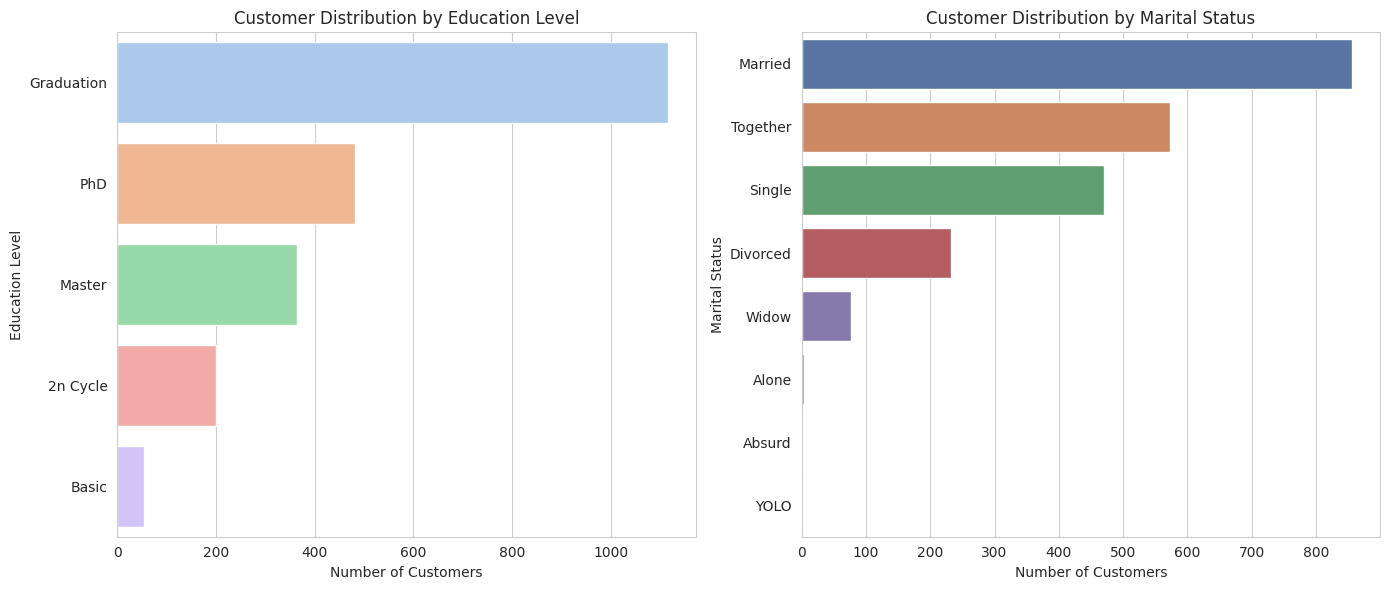

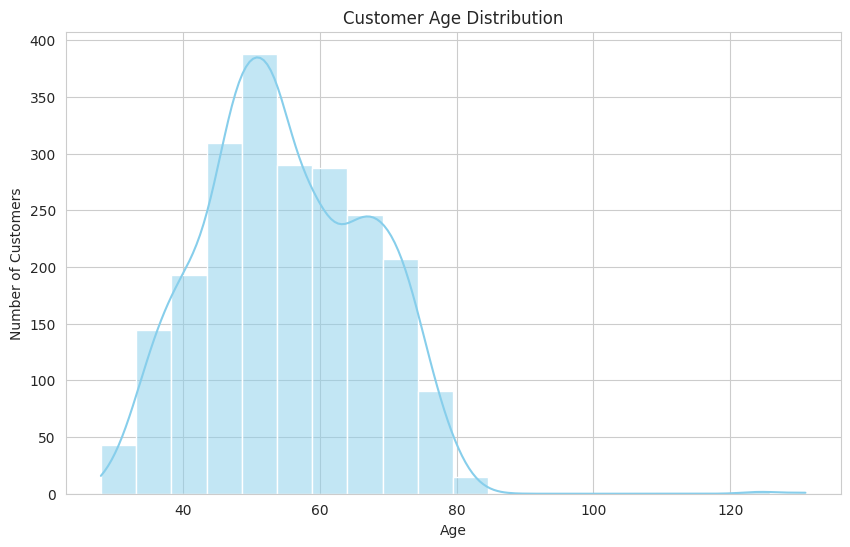

In [27]:
# Demographic breakdown (Education, Marital_Status)
plt.figure(figsize=(14, 6))
plt.subplot(1, 2, 1)
sns.countplot(data=df, y='Education', palette='pastel', order=df['Education'].value_counts().index)
plt.title('Customer Distribution by Education Level')
plt.xlabel('Number of Customers')
plt.ylabel('Education Level')

plt.subplot(1, 2, 2)
sns.countplot(data=df, y='Marital_Status', palette='deep', order=df['Marital_Status'].value_counts().index)
plt.title('Customer Distribution by Marital Status')
plt.xlabel('Number of Customers')
plt.ylabel('Marital Status')
plt.tight_layout()
plt.show()

# Age distribution
df['Age'] = 2024 - df['Year_Birth'] # Assuming current year is 2024
plt.figure(figsize=(10, 6))
sns.histplot(df['Age'], bins=20, kde=True, color='skyblue')
plt.title('Customer Age Distribution')
plt.xlabel('Age')
plt.ylabel('Number of Customers')
plt.show()

### Relationship Between Demographics and Spending Behavior

/tmp/ipykernel_628/996656055.py:3: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(data=df, x='Education', y='Total_Spending', palette='viridis', ci=None)
/tmp/ipykernel_628/996656055.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, x='Education', y='Total_Spending', palette='viridis', ci=None)


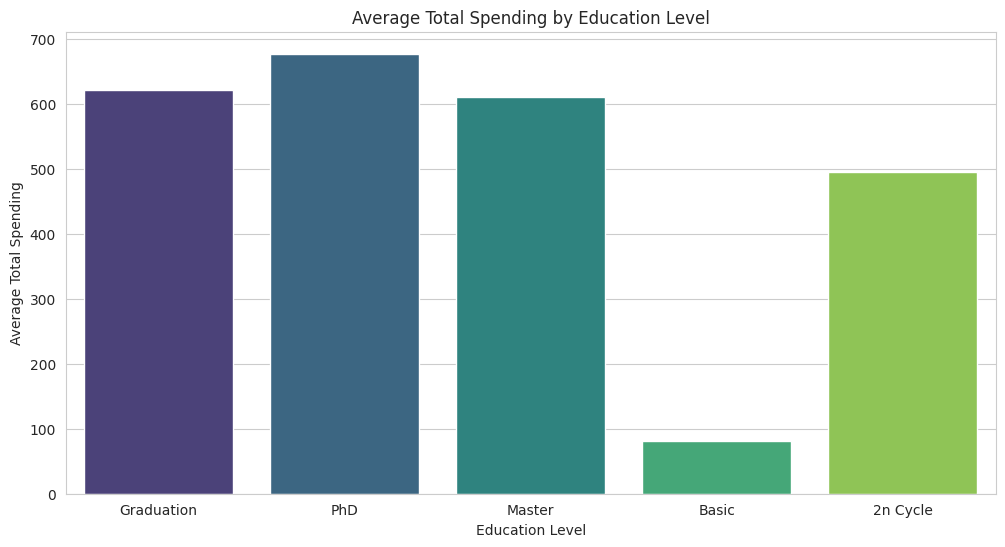

/tmp/ipykernel_628/996656055.py:11: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(data=df, x='Marital_Status', y='Total_Spending', palette='magma', ci=None)
/tmp/ipykernel_628/996656055.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, x='Marital_Status', y='Total_Spending', palette='magma', ci=None)


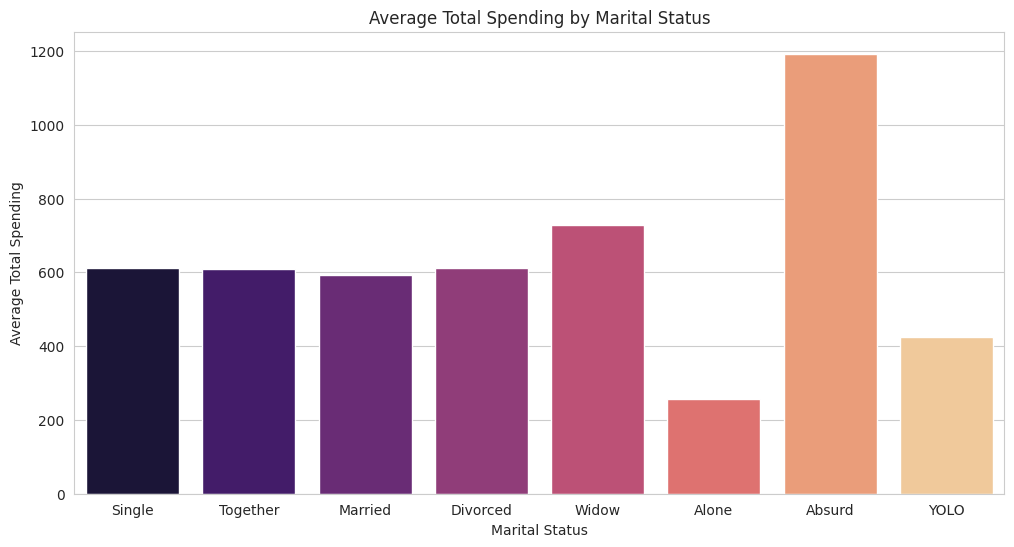

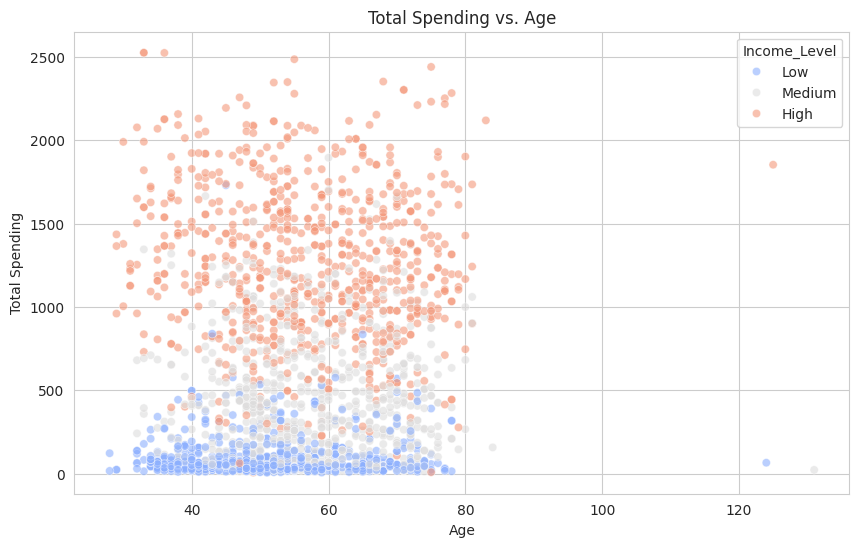

In [28]:
# Spending by Education Level
plt.figure(figsize=(12, 6))
sns.barplot(data=df, x='Education', y='Total_Spending', palette='viridis', ci=None)
plt.title('Average Total Spending by Education Level')
plt.xlabel('Education Level')
plt.ylabel('Average Total Spending')
plt.show()

# Spending by Marital Status
plt.figure(figsize=(12, 6))
sns.barplot(data=df, x='Marital_Status', y='Total_Spending', palette='magma', ci=None)
plt.title('Average Total Spending by Marital Status')
plt.xlabel('Marital Status')
plt.ylabel('Average Total Spending')
plt.show()

# Spending by Age (using scatter plot or bins)
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='Age', y='Total_Spending', hue='Income_Level', palette='coolwarm', alpha=0.6)
plt.title('Total Spending vs. Age')
plt.xlabel('Age')
plt.ylabel('Total Spending')
plt.show()

### Visualize Campaign Response Rates

/tmp/ipykernel_628/3809500152.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='Response', palette='cividis')


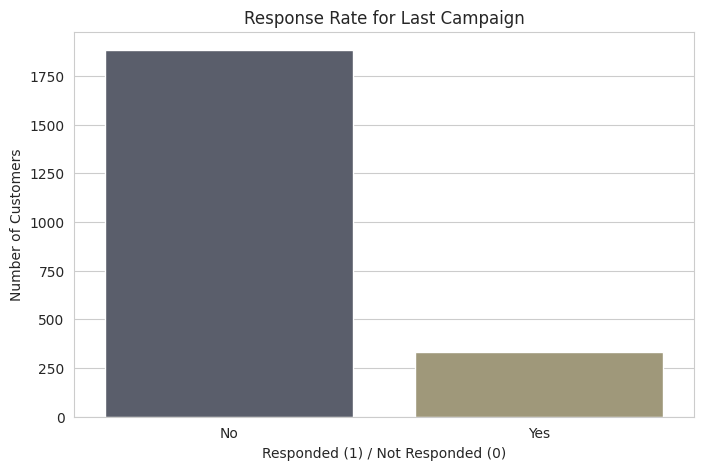

/tmp/ipykernel_628/3809500152.py:12: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(data=df, x='Loyalty_Status', y='Response', palette='YlGnBu', ci=None)
/tmp/ipykernel_628/3809500152.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, x='Loyalty_Status', y='Response', palette='YlGnBu', ci=None)


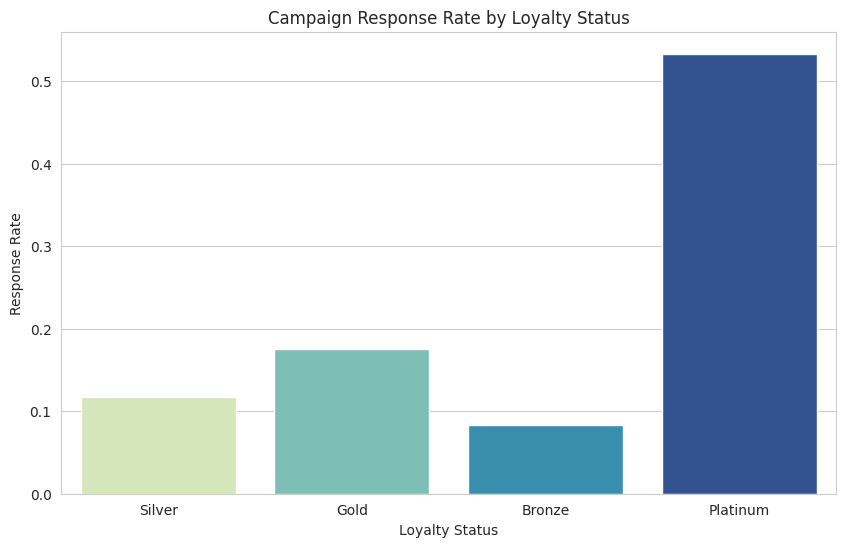

/tmp/ipykernel_628/3809500152.py:20: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(data=df, x='Preferred_Channel', y='Response', palette='rocket', ci=None)
/tmp/ipykernel_628/3809500152.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, x='Preferred_Channel', y='Response', palette='rocket', ci=None)


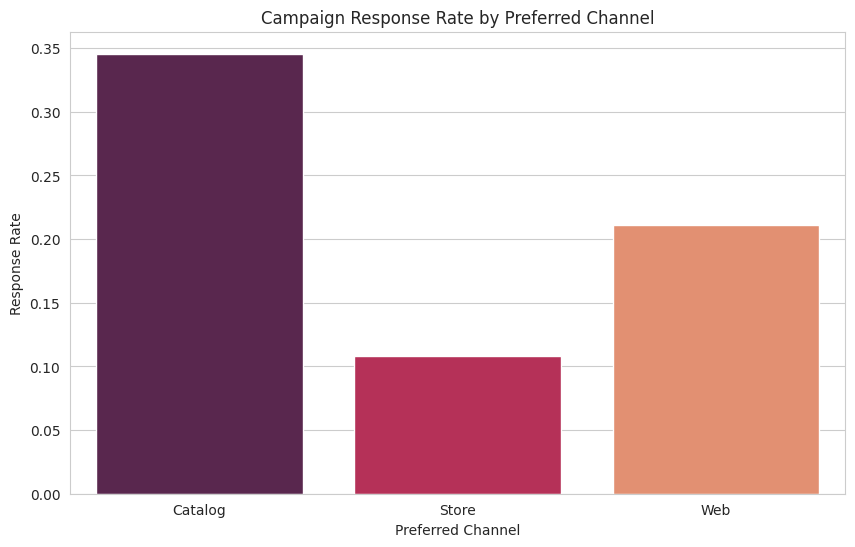

In [29]:
# Response rates for the last campaign (Response column)
plt.figure(figsize=(8, 5))
sns.countplot(data=df, x='Response', palette='cividis')
plt.title('Response Rate for Last Campaign')
plt.xlabel('Responded (1) / Not Responded (0)')
plt.ylabel('Number of Customers')
plt.xticks(ticks=[0, 1], labels=['No', 'Yes'])
plt.show()

# Response rate by Loyalty Status
plt.figure(figsize=(10, 6))
sns.barplot(data=df, x='Loyalty_Status', y='Response', palette='YlGnBu', ci=None)
plt.title('Campaign Response Rate by Loyalty Status')
plt.xlabel('Loyalty Status')
plt.ylabel('Response Rate')
plt.show()

# Response rate by Preferred Channel
plt.figure(figsize=(10, 6))
sns.barplot(data=df, x='Preferred_Channel', y='Response', palette='rocket', ci=None)
plt.title('Campaign Response Rate by Preferred Channel')
plt.xlabel('Preferred Channel')
plt.ylabel('Response Rate')
plt.show()

### Detecting Outliers

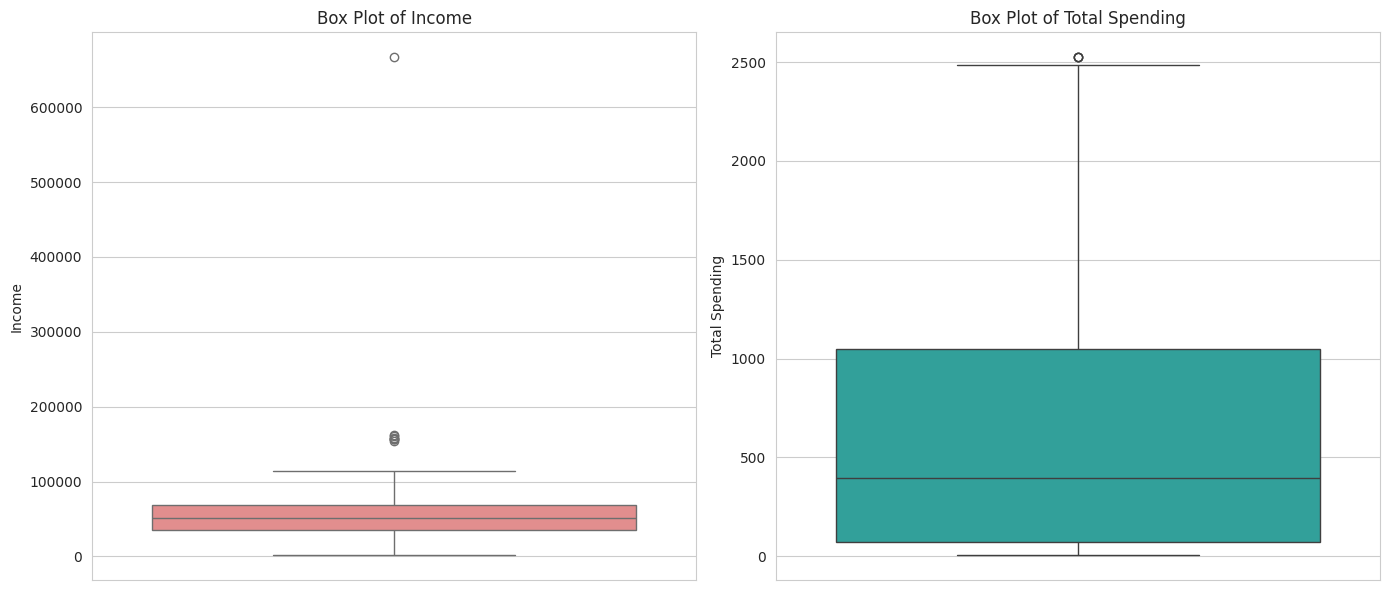

In [30]:
# Outliers in Income and Total_Spending using box plots
plt.figure(figsize=(14, 6))
plt.subplot(1, 2, 1)
sns.boxplot(y=df['Income'], color='lightcoral')
plt.title('Box Plot of Income')
plt.ylabel('Income')

plt.subplot(1, 2, 2)
sns.boxplot(y=df['Total_Spending'], color='lightseagreen')
plt.title('Box Plot of Total Spending')
plt.ylabel('Total Spending')
plt.tight_layout()
plt.show()

### Correlation Heatmap

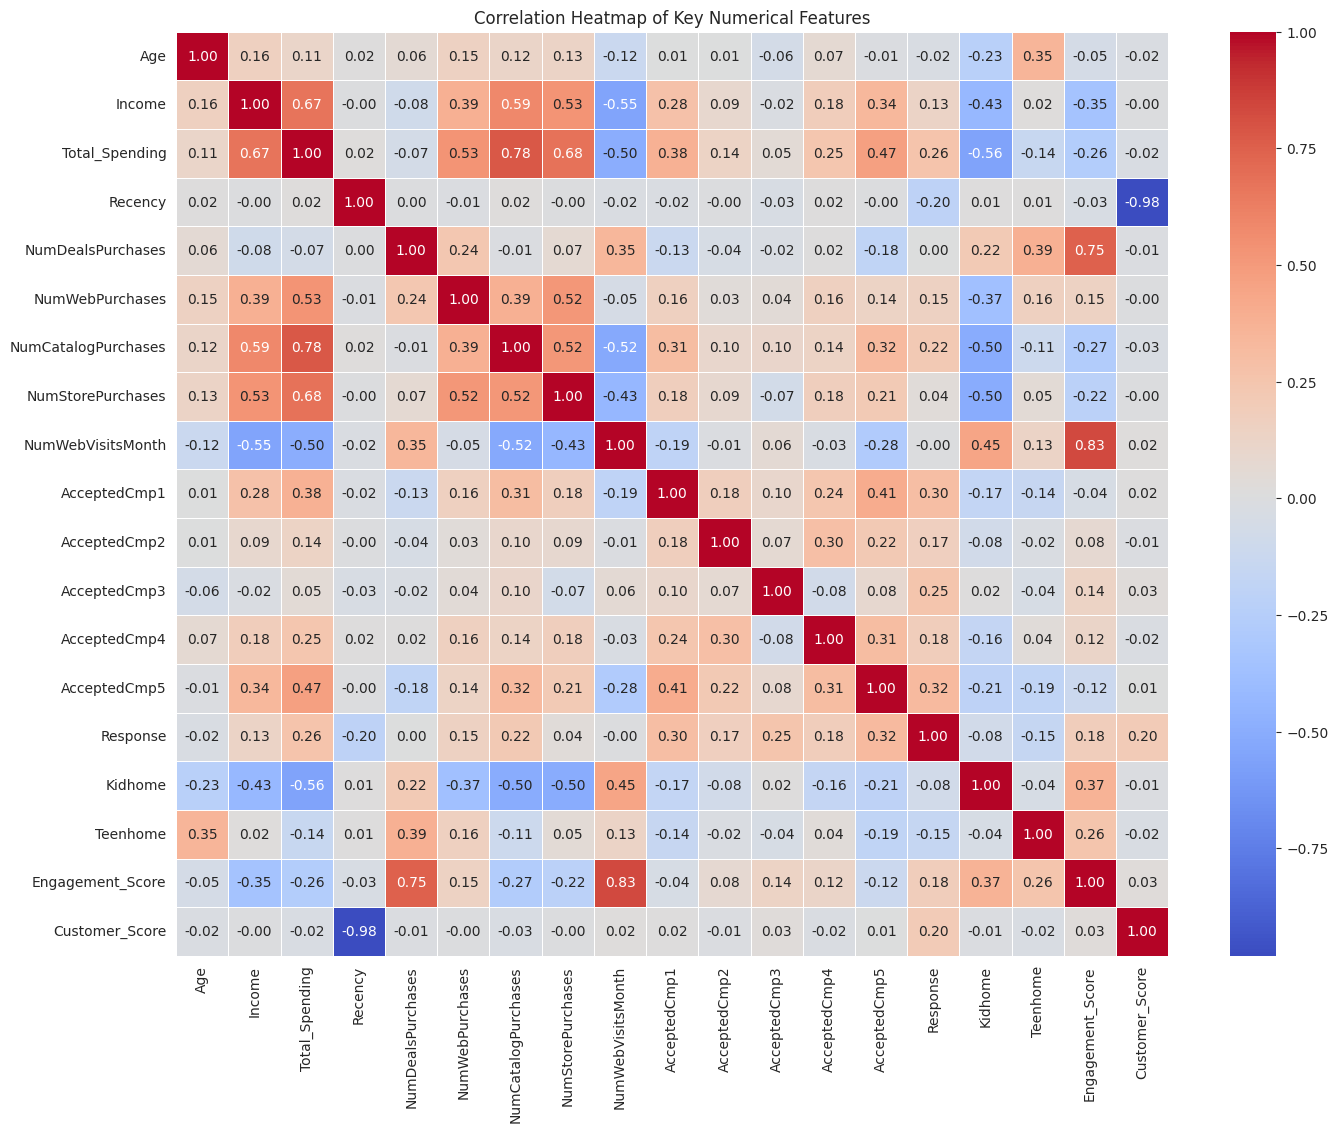

In [31]:
# Select numerical features for correlation
correlation_features = [
    'Age', 'Income', 'Total_Spending', 'Recency',
    'NumDealsPurchases', 'NumWebPurchases', 'NumCatalogPurchases', 'NumStorePurchases', 'NumWebVisitsMonth',
    'AcceptedCmp1', 'AcceptedCmp2', 'AcceptedCmp3', 'AcceptedCmp4', 'AcceptedCmp5', 'Response',
    'Kidhome', 'Teenhome', 'Engagement_Score', 'Customer_Score'
]

# Ensure all features exist in the DataFrame before selecting
correlation_features = [col for col in correlation_features if col in df.columns]

corr_matrix = df[correlation_features].corr()

plt.figure(figsize=(16, 12))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5)
plt.title('Correlation Heatmap of Key Numerical Features')
plt.show()